<a href="https://colab.research.google.com/github/tanusreemajumder/Neural-Networks-Andrew-Ng/blob/main/part_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

np.random.seed(1)
print("NumPy version:", np.__version__)

NumPy version: 2.1.3


## 1. Why Look at Case Studies?

Almost nobody designs a CNN architecture from a blank page. Good architectures are **found by years of trial and error**, and the *ideas* inside them transfer: a trick invented for ImageNet classification (residual connections, 1x1 bottlenecks, parallel filter sizes) turns up again in detection, segmentation, even speech and language models. Reading the classics is how you build intuition for what to try on your own problem.

The rest of this notebook is a tour in roughly historical order, each stop adding one reusable idea:

| Network | Year | Idea it contributed |
|---|---|---|
| LeNet-5 | 1998 | conv -> pool -> conv -> pool -> fully connected; shrink height/width, grow channels |
| AlexNet | 2012 | same pattern, scaled up; ReLU, dropout, GPUs |
| VGG-16 | 2014 | radical simplicity: only 3x3 convs and 2x2 max pools, channels double after each pool |
| ResNet | 2015 | skip connections make *very* deep networks (50, 101, 152 layers) trainable |
| Inception | 2014 | do several filter sizes in parallel, use 1x1 convs to keep it cheap |

Two small helpers used everywhere below: the parameter count of a conv layer, $n_c^{[l]}\,(f\cdot f\cdot n_c^{[l-1]}+1)$, and of a dense layer, $n_{out}(n_{in}+1)$.

In [2]:
def conv_params(f, c_in, n_filters):
    return n_filters * (f * f * c_in + 1)

def dense_params(n_in, n_out):
    return n_out * n_in + n_out

# Approximate, from the original papers / common implementations (for orientation only)
landmarks = [
    ("LeNet-5",               1998, 5,  "~60 thousand"),
    ("AlexNet",               2012, 8,  "~60 million"),
    ("VGG-16",                2014, 16, "~138 million"),
    ("Inception (GoogLeNet)", 2014, 22, "~7 million"),
    ("ResNet-50",             2015, 50, "~25 million"),
]
print(f"{'network':>22} | {'year':>4} | {'layers with weights':>19} | {'parameters':>14}")
print("-" * 70)
for name, year, depth, params in landmarks:
    print(f"{name:>22} | {year:>4} | {depth:>19} | {params:>14}")

print("\nNotice: depth and parameter count are NOT the same thing. Inception is deeper than VGG-16")
print("but has ~20x fewer parameters; ResNet-50 is 3x deeper than VGG-16 with ~5x fewer parameters.")
print("Smarter architecture (1x1 bottlenecks, no huge fully-connected layers) beats brute force.")

               network | year | layers with weights |     parameters
----------------------------------------------------------------------
               LeNet-5 | 1998 |                   5 |   ~60 thousand
               AlexNet | 2012 |                   8 |    ~60 million
                VGG-16 | 2014 |                  16 |   ~138 million
 Inception (GoogLeNet) | 2014 |                  22 |     ~7 million
             ResNet-50 | 2015 |                  50 |    ~25 million

Notice: depth and parameter count are NOT the same thing. Inception is deeper than VGG-16
but has ~20x fewer parameters; ResNet-50 is 3x deeper than VGG-16 with ~5x fewer parameters.
Smarter architecture (1x1 bottlenecks, no huge fully-connected layers) beats brute force.


## 2. Classic Networks

All three classics share one pattern: **height and width shrink, channels grow, then fully connected layers finish the job.**

- **LeNet-5** (LeCun, 1998): 32x32x1 grayscale digits, about 60 thousand parameters. Conv (5x5) -> average pool -> conv -> average pool -> FC 120 -> FC 84 -> output. Used sigmoid/tanh, not ReLU.
- **AlexNet** (Krizhevsky et al., 2012): 227x227x3 input, much bigger (tens of millions of parameters), **ReLU**, max pooling, dropout. The result that convinced the vision community that deep learning works.
- **VGG-16** (Simonyan & Zisserman, 2014): throw away all the design choices and use only **3x3 conv, stride 1, same padding** and **2x2 max pool, stride 2**. The number of filters doubles after each pool group (64 -> 128 -> 256 -> 512). Very uniform and easy to reason about, but ~138 million parameters.

The most useful skill for reading any architecture paper is the **dimension table**: track $(n_H, n_W, n_C)$ and the parameter count layer by layer. The output size formula is the one from the last notebook:
$$n_{out} = \left\lfloor \frac{n_{in} + 2p - f}{s} \right\rfloor + 1$$

We build one function that takes a list of layer specs and prints the table, then run it on all three networks.

In [3]:
def cnn_table(input_shape, specs, title):
    """Print a layer-by-layer dimension / parameter table.
    specs entries: ("conv", f, n_filters, stride, pad), ("pool", f, stride), ("dense", n_units).
    A dense layer after a conv/pool layer implicitly flattens the volume first."""
    h, w, c = input_shape
    flat = None
    total = 0
    rows = [("input", f"{h}x{w}x{c}", h * w * c, 0)]
    for spec in specs:
        if spec[0] == "conv":
            _, f, n, s, p = spec
            p_count = conv_params(f, c, n)
            h = (h + 2 * p - f) // s + 1
            w = (w + 2 * p - f) // s + 1
            c = n
            label = f"conv {f}x{f}, {n} filters, s={s}, p={p}"
            rows.append((label, f"{h}x{w}x{c}", h * w * c, p_count))
        elif spec[0] == "pool":
            _, f, s = spec
            h = (h - f) // s + 1
            w = (w - f) // s + 1
            p_count = 0
            rows.append((f"pool {f}x{f}, s={s}", f"{h}x{w}x{c}", h * w * c, 0))
        else:
            _, n = spec
            n_in = flat if flat is not None else h * w * c
            p_count = dense_params(n_in, n)
            flat = n
            rows.append((f"dense {n}", f"{n}", n, p_count))
        total += p_count
    print(f"=== {title} ===")
    print(f"{'layer':<34} | {'output shape':>13} | {'activations':>11} | {'parameters':>12}")
    print("-" * 80)
    for label, shape, acts, pc in rows:
        print(f"{label:<34} | {shape:>13} | {acts:>11,} | {pc:>12,}")
    print("-" * 80)
    print(f"{'TOTAL PARAMETERS':<34} | {'':>13} | {'':>11} | {total:>12,}\n")
    return rows, total

# ---- LeNet-5 (the version in the course: avg pool, 32x32x1 input)
lenet_specs = [("conv", 5, 6, 1, 0), ("pool", 2, 2), ("conv", 5, 16, 1, 0), ("pool", 2, 2),
               ("dense", 120), ("dense", 84), ("dense", 10)]
_, lenet_total = cnn_table((32, 32, 1), lenet_specs, "LeNet-5")

# ---- AlexNet (un-grouped version; the original split filters across two GPUs, ~60M total)
alexnet_specs = [("conv", 11, 96, 4, 0), ("pool", 3, 2),
                 ("conv", 5, 256, 1, 2), ("pool", 3, 2),
                 ("conv", 3, 384, 1, 1), ("conv", 3, 384, 1, 1), ("conv", 3, 256, 1, 1), ("pool", 3, 2),
                 ("dense", 4096), ("dense", 4096), ("dense", 1000)]
_, alexnet_total = cnn_table((227, 227, 3), alexnet_specs, "AlexNet (un-grouped)")

# ---- VGG-16
vgg_specs = []
for n_convs, n_filters in [(2, 64), (2, 128), (3, 256), (3, 512), (3, 512)]:
    vgg_specs += [("conv", 3, n_filters, 1, 1)] * n_convs + [("pool", 2, 2)]
vgg_specs += [("dense", 4096), ("dense", 4096), ("dense", 1000)]
vgg_rows, vgg_total = cnn_table((224, 224, 3), vgg_specs, "VGG-16")

assert lenet_total == 61706 and vgg_total == 138357544
print("Both totals match the published numbers (LeNet-5: 61,706; VGG-16: 138,357,544).")

=== LeNet-5 ===
layer                              |  output shape | activations |   parameters
--------------------------------------------------------------------------------
input                              |       32x32x1 |       1,024 |            0
conv 5x5, 6 filters, s=1, p=0      |       28x28x6 |       4,704 |          156
pool 2x2, s=2                      |       14x14x6 |       1,176 |            0
conv 5x5, 16 filters, s=1, p=0     |      10x10x16 |       1,600 |        2,416
pool 2x2, s=2                      |        5x5x16 |         400 |            0
dense 120                          |           120 |         120 |       48,120
dense 84                           |            84 |          84 |       10,164
dense 10                           |            10 |          10 |          850
--------------------------------------------------------------------------------
TOTAL PARAMETERS                   |               |             |       61,706

=== AlexNet (un-group

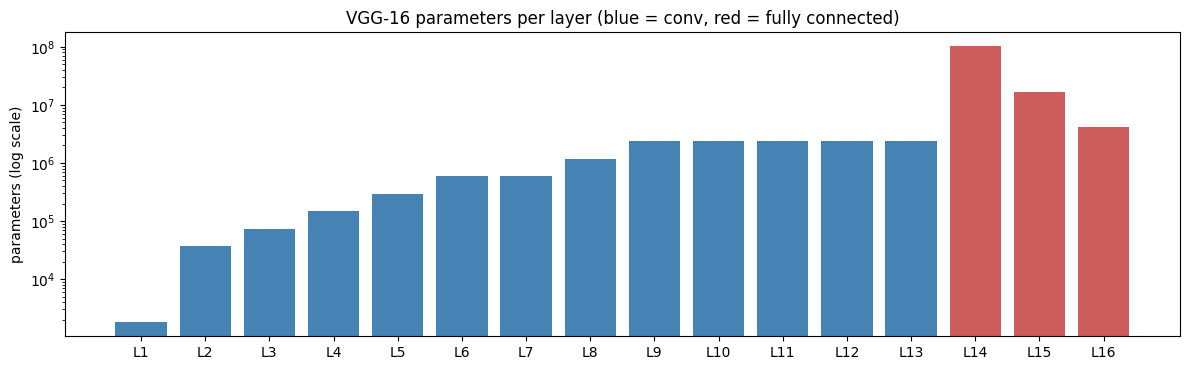

Fully connected layers hold 123,642,856 of 138,357,544 parameters (89.4%).
The first FC layer alone (7x7x512 = 25,088 inputs x 4096 units) is the biggest layer in the network.
Conv layers do most of the *computation*, FC layers hold most of the *parameters*.
That observation is exactly what ResNet and Inception exploit: no giant FC layers at the end.


In [4]:
# Where do VGG-16's parameters live? Plot parameters per layer (log scale).
layers = [(label, pc) for label, _, _, pc in vgg_rows if pc > 0]
names = [l.replace(", s=1, p=1", "").replace(" filters", "f") for l, _ in layers]
counts = np.array([pc for _, pc in layers])

fig, ax = plt.subplots(figsize=(12, 3.8))
colors = ["steelblue" if n.startswith("conv") else "indianred" for n in names]
ax.bar(range(len(counts)), counts, color=colors)
ax.set_yscale("log")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels([f"L{i+1}" for i in range(len(counts))])
ax.set_ylabel("parameters (log scale)")
ax.set_title("VGG-16 parameters per layer (blue = conv, red = fully connected)")
plt.tight_layout()
plt.show()

fc_params = counts[[n.startswith("dense") for n in names]].sum()
print(f"Fully connected layers hold {fc_params:,} of {counts.sum():,} parameters "
      f"({100 * fc_params / counts.sum():.1f}%).")
print("The first FC layer alone (7x7x512 = 25,088 inputs x 4096 units) is the biggest layer in the network.")
print("Conv layers do most of the *computation*, FC layers hold most of the *parameters*.")
print("That observation is exactly what ResNet and Inception exploit: no giant FC layers at the end.")

## 3. ResNets

Training very deep **plain** networks gets *harder*, not easier, beyond some depth: training error goes up as you add layers. Part of the reason is that the gradient (and the signal) has to pass through many multiplications and shrinks (or explodes) on the way. ResNets (He et al., 2015) add a **skip connection** (shortcut) that lets a layer's input jump ahead and be added in two layers later.

**Plain two-layer block:**
$$z^{[l+1]} = W^{[l+1]}a^{[l]} + b^{[l+1]},\quad a^{[l+1]} = g(z^{[l+1]}),\quad z^{[l+2]} = W^{[l+2]}a^{[l+1]} + b^{[l+2]},\quad a^{[l+2]} = g(z^{[l+2]})$$

**Residual block:** the only change is the last line
$$a^{[l+2]} = g\big(z^{[l+2]} + a^{[l]}\big)$$

The block only has to learn the **residual** $F(a^{[l]}) = a^{[l+2]}-a^{[l]}$ instead of the whole mapping. Stack many of these and you get a ResNet; the original paper trained 152-layer networks this way.

We need a working convolution first. Below is a **vectorized** version of the convolution from the previous notebook. Same math (it is still "slide the filter, multiply, sum"), but the loops run over the *filter offsets* ($f \times f$ of them) instead of over every output pixel, so it is fast enough for the experiments ahead. Stride is fixed at 1, which is all this notebook needs.

In [5]:
def relu(z):
    return np.maximum(0, z)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def conv_forward(A_prev, W, b, pad=0):
    """Stride-1 convolution on a batch.
    A_prev: (m, H, W, C_in)   W: (f, f, C_in, n_filters)   b: (n_filters,)
    Returns Z of shape (m, H+2p-f+1, W+2p-f+1, n_filters) and a cache for backprop."""
    m, H, Wd, c_in = A_prev.shape
    f = W.shape[0]
    Ap = np.pad(A_prev, ((0, 0), (pad, pad), (pad, pad), (0, 0))) if pad > 0 else A_prev
    oh, ow = H + 2 * pad - f + 1, Wd + 2 * pad - f + 1
    Z = np.zeros((m, oh, ow, W.shape[3])) + b
    for di in range(f):
        for dj in range(f):
            # every output pixel at once: (m, oh, ow, C_in) x (C_in, n_filters)
            Z += np.tensordot(Ap[:, di:di + oh, dj:dj + ow, :], W[di, dj], axes=([3], [0]))
    return Z, (A_prev, W, pad)

def conv_backward(dZ, cache):
    """Gradients of a conv layer. dZ: gradient w.r.t. Z, same shape as Z."""
    A_prev, W, pad = cache
    m, H, Wd, c_in = A_prev.shape
    f = W.shape[0]
    Ap = np.pad(A_prev, ((0, 0), (pad, pad), (pad, pad), (0, 0))) if pad > 0 else A_prev
    _, oh, ow, _ = dZ.shape
    dAp = np.zeros_like(Ap)
    dW = np.zeros_like(W)
    for di in range(f):
        for dj in range(f):
            patch = Ap[:, di:di + oh, dj:dj + ow, :]
            dW[di, dj] = np.tensordot(patch, dZ, axes=([0, 1, 2], [0, 1, 2]))
            dAp[:, di:di + oh, dj:dj + ow, :] += np.tensordot(dZ, W[di, dj], axes=([3], [1]))
    db = dZ.sum(axis=(0, 1, 2))
    dA_prev = dAp[:, pad:pad + H, pad:pad + Wd, :] if pad > 0 else dAp
    return dA_prev, dW, db

# ---- sanity check against the plain "loop over every output pixel" definition
def conv_naive(A, W, b, pad):
    m, H, Wd, c_in = A.shape
    f, _, _, n = W.shape
    Ap = np.pad(A, ((0, 0), (pad, pad), (pad, pad), (0, 0)))
    oh, ow = H + 2 * pad - f + 1, Wd + 2 * pad - f + 1
    Z = np.zeros((m, oh, ow, n))
    for i in range(m):
        for y in range(oh):
            for x in range(ow):
                for k in range(n):
                    Z[i, y, x, k] = np.sum(Ap[i, y:y + f, x:x + f, :] * W[:, :, :, k]) + b[k]
    return Z

rng = np.random.RandomState(0)
A_test = rng.randn(2, 6, 7, 3)
W_test, b_test = rng.randn(3, 3, 3, 4), rng.randn(4)
for pad in (0, 1):
    Z_fast, _ = conv_forward(A_test, W_test, b_test, pad)
    print(f"pad={pad}: output shape {Z_fast.shape}, matches naive loops: "
          f"{np.allclose(Z_fast, conv_naive(A_test, W_test, b_test, pad))}")

pad=0: output shape (2, 4, 5, 4), matches naive loops: True
pad=1: output shape (2, 6, 7, 4), matches naive loops: True


In [6]:
# ---- (a) A residual block made of convolutions ("same" convs so shapes line up)
def residual_block_conv(A, W1, b1, W2, b2, Ws=None):
    """a[l+2] = relu(conv(relu(conv(a[l]))) + shortcut(a[l])).
    If the channel count changes, the shortcut needs a 1x1 conv projection Ws."""
    Z1, _ = conv_forward(A, W1, b1, pad=1)
    A1 = relu(Z1)
    Z2, _ = conv_forward(A1, W2, b2, pad=1)
    if Ws is None:
        shortcut = A
    else:
        shortcut, _ = conv_forward(A, Ws, np.zeros(Ws.shape[3]), pad=0)
    return relu(Z2 + shortcut)

rng = np.random.RandomState(1)
A = relu(rng.randn(2, 8, 8, 4))                       # a[l]: 2 images, 8x8, 4 channels

# same number of channels: identity shortcut
W1, b1 = rng.randn(3, 3, 4, 4) * 0.2, np.zeros(4)
W2, b2 = rng.randn(3, 3, 4, 4) * 0.2, np.zeros(4)
out_same = residual_block_conv(A, W1, b1, W2, b2)
print("identity shortcut :", A.shape, "->", out_same.shape)

# channels 4 -> 8: needs Ws (a 1x1 conv) so that the two terms can be added
W1c, W2c = rng.randn(3, 3, 4, 8) * 0.2, rng.randn(3, 3, 8, 8) * 0.2
Ws = rng.randn(1, 1, 4, 8) * 0.2
out_proj = residual_block_conv(A, W1c, np.zeros(8), W2c, np.zeros(8), Ws)
print("projection shortcut:", A.shape, "->", out_proj.shape, " (Ws is a 1x1 conv, 4 -> 8 channels)")

identity shortcut : (2, 8, 8, 4) -> (2, 8, 8, 4)
projection shortcut: (2, 8, 8, 4) -> (2, 8, 8, 8)  (Ws is a 1x1 conv, 4 -> 8 channels)


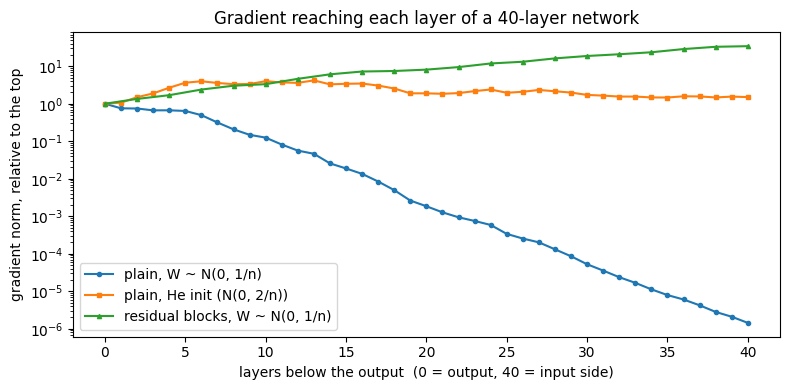

Gradient at the first layer relative to the top, 40 layers:
  plain, N(0,1/n)        : 1.43e-06   <- the signal has all but vanished
  plain, He init         : 1.50e+00
  residual, N(0,1/n)     : 3.42e+01

Honest reading: careful initialization (He) also rescues a plain net's gradient, and ResNets fix an
optimization problem that is bigger than gradient size alone. But the skip path is what guarantees
a direct route for the gradient (the '+ dz2' term), whatever the weights happen to be.


In [7]:
# ---- (b) Why depth hurts plain networks: follow the gradient through a deep stack of layers.
# Fully connected layers (n units each) keep this experiment short; the argument is identical for conv layers.
def gradient_norms(L, residual, scale, n=32, m=64, seed=0):
    """Forward through L layers, then backprop a gradient of ones from the top.
    Returns ||dL/da|| at every layer, from the output (index 0) down to the input.
    scale = variance multiplier for the weights: W ~ N(0, scale/n). scale=2 is He initialization."""
    rng = np.random.RandomState(seed)
    a = rng.randn(n, m)
    if not residual:
        Ws, zs = [], []
        for _ in range(L):
            W = rng.randn(n, n) * np.sqrt(scale / n)
            z = W @ a
            a = relu(z)
            Ws.append(W); zs.append(z)
        da = np.ones((n, m))
        norms = [np.linalg.norm(da)]
        for W, z in zip(reversed(Ws), reversed(zs)):
            da = W.T @ (da * (z > 0))
            norms.append(np.linalg.norm(da))
        return np.array(norms)
    # residual: L layers = L/2 blocks, a_out = relu(W2 relu(W1 a) + a)
    blocks = []
    for _ in range(L // 2):
        W1 = rng.randn(n, n) * np.sqrt(scale / n)
        W2 = rng.randn(n, n) * np.sqrt(scale / n)
        z1 = W1 @ a; a1 = relu(z1)
        z2 = W2 @ a1 + a
        blocks.append((W1, W2, z1, z2))
        a = relu(z2)
    da = np.ones((n, m))
    norms = [np.linalg.norm(da)]
    for W1, W2, z1, z2 in reversed(blocks):
        dz2 = da * (z2 > 0)
        da1 = W2.T @ dz2
        da = W1.T @ (da1 * (z1 > 0)) + dz2            # <- the "+ dz2" is the gradient flowing down the skip path
        norms.extend([np.nan, np.linalg.norm(da)])    # one data point per block (2 layers)
    return np.array(norms)

L = 40
plain      = gradient_norms(L, residual=False, scale=1.0)
plain_he   = gradient_norms(L, residual=False, scale=2.0)
resid      = gradient_norms(L, residual=True,  scale=1.0)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(L + 1)
ax.semilogy(x, plain / plain[0], "o-", ms=3, label="plain, W ~ N(0, 1/n)")
ax.semilogy(x, plain_he / plain_he[0], "s-", ms=3, label="plain, He init (N(0, 2/n))")
ok = ~np.isnan(resid)
ax.semilogy(x[ok], (resid / resid[0])[ok], "^-", ms=3, label="residual blocks, W ~ N(0, 1/n)")
ax.set_xlabel("layers below the output  (0 = output, 40 = input side)")
ax.set_ylabel("gradient norm, relative to the top")
ax.set_title(f"Gradient reaching each layer of a {L}-layer network")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Gradient at the first layer relative to the top, {L} layers:")
print(f"  plain, N(0,1/n)        : {plain[-1] / plain[0]:.2e}   <- the signal has all but vanished")
print(f"  plain, He init         : {plain_he[-1] / plain_he[0]:.2e}")
print(f"  residual, N(0,1/n)     : {resid[-1] / resid[0]:.2e}")
print("\nHonest reading: careful initialization (He) also rescues a plain net's gradient, and ResNets fix an")
print("optimization problem that is bigger than gradient size alone. But the skip path is what guarantees")
print("a direct route for the gradient (the '+ dz2' term), whatever the weights happen to be.")

## 4. Why ResNets Work

The key observation: **a residual block can easily learn the identity function.**

$$a^{[l+2]} = g\big(\underbrace{W^{[l+2]}a^{[l+1]} + b^{[l+2]}}_{z^{[l+2]}} + a^{[l]}\big)$$

If the weights and biases of the block shrink to zero (L2 regularization pushes them that way), then $z^{[l+2]} = 0$ and

$$a^{[l+2]} = g(a^{[l]}) = a^{[l]} \quad\text{(because } a^{[l]}\ge 0 \text{ after a ReLU)}$$

So the extra two layers **do no harm** - they pass the input straight through. Now anything they learn beyond that is a bonus. Compare a *plain* network: to learn the identity through two layers, the weights must be tuned to a very specific configuration, which gradient descent rarely finds on its own. That is why adding layers to a plain net can hurt, but adding blocks to a ResNet "at least doesn't hurt".

A practical detail: $z^{[l+2]}$ and $a^{[l]}$ must have the **same dimensions** to be added. That is why ResNets use "same" convolutions inside a block, and a matrix $W_s$ (a 1x1 conv, as in Section 3) when the shapes change.

In [8]:
rng = np.random.RandomState(3)
n = 16
a_l = relu(rng.randn(n, 5))                         # a[l]: non-negative, like any post-ReLU activation

# (a) block with all weights and biases at zero
W1 = np.zeros((n, n)); W2 = np.zeros((n, n))
plain_out = relu(W2 @ relu(W1 @ a_l))               # plain 2-layer block
resid_out = relu(W2 @ relu(W1 @ a_l) + a_l)         # residual block
print("zero weights:")
print("  plain block output is all zeros      :", bool(np.all(plain_out == 0)), "  (information destroyed)")
print("  residual block output equals its input:", bool(np.allclose(resid_out, a_l)), "  (identity for free)")

# (b) insert k extra blocks with small random weights into an existing network
def insert_blocks(a, k, residual, std, seed):
    rng = np.random.RandomState(seed)
    for _ in range(k):
        W1 = rng.randn(n, n) * std
        W2 = rng.randn(n, n) * std
        if residual:
            a = relu(W2 @ relu(W1 @ a) + a)
        else:
            a = relu(W2 @ relu(W1 @ a))
    return a

print("\nInsert k extra blocks with small random weights (std 0.05).")
print("Relative change of the activations, ||a_new - a|| / ||a||  (0 = network untouched):\n")
print(f"{'k extra blocks':>15} | {'plain':>8} | {'residual':>8}")
print("-" * 40)
for k in (1, 2, 5, 10, 20):
    changes = []
    for residual in (False, True):
        a_new = insert_blocks(a_l, k, residual, std=0.05, seed=7)
        changes.append(np.linalg.norm(a_new - a_l) / np.linalg.norm(a_l))
    print(f"{k:>15} | {changes[0]:>8.3f} | {changes[1]:>8.3f}")

print("\nPlain: the inserted layers wipe out the signal (change ~ 1.0 means almost nothing of a[l] survives).")
print("Residual: the original signal is still there; the new blocks only add a small perturbation.")
print("This is the mechanism: starting from the 'do nothing' solution, extra depth can only refine the result.")

zero weights:
  plain block output is all zeros      : True   (information destroyed)
  residual block output equals its input: True   (identity for free)

Insert k extra blocks with small random weights (std 0.05).
Relative change of the activations, ||a_new - a|| / ||a||  (0 = network untouched):

 k extra blocks |    plain | residual
----------------------------------------
              1 |    0.999 |    0.016
              2 |    1.000 |    0.028
              5 |    1.000 |    0.056
             10 |    1.000 |    0.083
             20 |    1.000 |    0.124

Plain: the inserted layers wipe out the signal (change ~ 1.0 means almost nothing of a[l] survives).
Residual: the original signal is still there; the new blocks only add a small perturbation.
This is the mechanism: starting from the 'do nothing' solution, extra depth can only refine the result.


## 5. Network in Network (1x1 Convolutions)

A 1x1 convolution looks pointless at first: a filter of size 1x1 on a single-channel image just **multiplies every pixel by one number**. But on a volume with many channels it is something very different. A filter of shape $1\times1\times n_C$ takes the $n_C$ numbers at one pixel position, computes a weighted sum, and applies a ReLU. With $n_C'$ filters this is a **fully connected layer applied independently at every pixel position, mixing information across channels** (Lin et al., "Network in Network", 2013).

Two uses:
1. **Shrink or grow the number of channels** ($n_C \to n_C'$) without touching height and width. Pooling shrinks $n_H, n_W$; a 1x1 conv shrinks $n_C$.
2. **Add non-linearity** (and more capacity) cheaply inside a network.

The big payoff is the **bottleneck**: squeeze channels with a 1x1 conv *before* an expensive conv. The cost of a conv layer is the number of multiplications
$$\text{cost} = n_H^{out}\cdot n_W^{out}\cdot n_C^{out}\cdot (f\cdot f\cdot n_C^{in})$$

Example from the Inception paper's setting: input $28\times28\times192$, want $28\times28\times32$ out with a 5x5 conv.

In [9]:
def conv_mults(h_out, w_out, c_in, c_out, f):
    """Multiplications needed by a conv layer."""
    return h_out * w_out * c_out * f * f * c_in

def conv1x1(volume, W, b=None):
    """1x1 convolution. volume: (m, H, W, C_in), W: (C_in, C_out). Same H, W out."""
    out = np.tensordot(volume, W, axes=([3], [0]))
    return out if b is None else out + b

rng = np.random.RandomState(0)

# (1) What it really is: a dense layer applied at every pixel.
vol = rng.randn(2, 5, 5, 6)
W = rng.randn(6, 3)
fast = conv1x1(vol, W)
slow = np.zeros((2, 5, 5, 3))
for i in range(2):
    for y in range(5):
        for x in range(5):
            slow[i, y, x, :] = vol[i, y, x, :] @ W        # one pixel = one small matrix-vector product
as_conv, _ = conv_forward(vol, W.reshape(1, 1, 6, 3), np.zeros(3), pad=0)
print("1x1 conv == per-pixel dense layer :", np.allclose(fast, slow))
print("1x1 conv == conv_forward with f=1 :", np.allclose(fast, as_conv))

# (2) On a single channel it is just a scaling.
one_channel = rng.randn(1, 4, 4, 1)
scaled = conv1x1(one_channel, np.array([[2.5]]))
print("single channel, filter [2.5]      :", np.allclose(scaled, 2.5 * one_channel), "(every pixel x 2.5)")

# (3) Shrinking channels while keeping height and width
big = rng.randn(1, 28, 28, 192)
small = relu(conv1x1(big, rng.randn(192, 32) * 0.1))
print(f"\nchannel reduction: {big.shape} -> {small.shape}")

1x1 conv == per-pixel dense layer : True
1x1 conv == conv_forward with f=1 : True
single channel, filter [2.5]      : True (every pixel x 2.5)

channel reduction: (1, 28, 28, 192) -> (1, 28, 28, 32)


Direct 5x5 conv, 192 -> 32 channels          :  120,422,400 multiplications
  1x1 conv, 192 -> 16 (bottleneck)           :    2,408,448
  5x5 conv,  16 -> 32                        :   10,035,200
Bottleneck total                             :   12,443,648 multiplications

Same output shape (28x28x32), 9.7x cheaper.


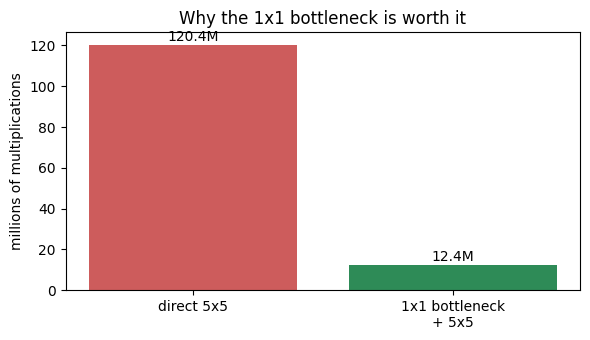

Shrinking to 16 channels in the middle did not hurt the network in practice: neighbouring channels
are highly correlated, so the 192-channel input holds far less information than its size suggests.


In [10]:
# The bottleneck saving: 28x28x192 -> 28x28x32 with 5x5 filters
direct = conv_mults(28, 28, 192, 32, 5)

step1 = conv_mults(28, 28, 192, 16, 1)      # 1x1 conv: 192 -> 16 channels  (the bottleneck)
step2 = conv_mults(28, 28, 16, 32, 5)       # 5x5 conv on the thin volume: 16 -> 32 channels
bottleneck = step1 + step2

print(f"Direct 5x5 conv, 192 -> 32 channels          : {direct:>12,} multiplications")
print(f"  1x1 conv, 192 -> 16 (bottleneck)           : {step1:>12,}")
print(f"  5x5 conv,  16 -> 32                        : {step2:>12,}")
print(f"Bottleneck total                             : {bottleneck:>12,} multiplications")
print(f"\nSame output shape (28x28x32), {direct / bottleneck:.1f}x cheaper.")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(["direct 5x5", "1x1 bottleneck\n+ 5x5"], [direct / 1e6, bottleneck / 1e6], color=["indianred", "seagreen"])
ax.set_ylabel("millions of multiplications")
ax.set_title("Why the 1x1 bottleneck is worth it")
for i, v in enumerate([direct / 1e6, bottleneck / 1e6]):
    ax.text(i, v + 2, f"{v:.1f}M", ha="center")
plt.tight_layout()
plt.show()

print("Shrinking to 16 channels in the middle did not hurt the network in practice: neighbouring channels")
print("are highly correlated, so the 192-channel input holds far less information than its size suggests.")

## 6. Inception Network Motivation

When designing a layer, you face a menu: a 1x1 conv? 3x3? 5x5? a max pool? The Inception idea (Szegedy et al., 2014) is: **don't choose, do them all in parallel and concatenate the results along the channel axis.** The network can learn which filter sizes matter at each stage.

For the outputs to be concatenated, all branches must produce the same height and width, so they use "same" padding (the pooling branch uses stride 1 and same padding too).

The catch is **computational cost**. Take $28\times28\times192$ in and the module below out: 64 1x1 filters, 128 3x3 filters, 32 5x5 filters, and a pooling branch with 32 channels, giving $28\times28\times(64+128+32+32)=28\times28\times256$.

The fix is the bottleneck from Section 5: put a 1x1 conv *before* the 3x3 (96 channels) and the 5x5 (16 channels) convs, and a 1x1 conv *after* the pooling branch (to shrink its 192 channels to 32).

Naive Inception module (28x28x192 in):
  1x1 (64)                   9,633,792
  3x3 (128)                173,408,256
  5x5 (32)                 120,422,400
  TOTAL                    303,464,448

With 1x1 bottlenecks:
  1x1 (64)                   9,633,792
  3x3 reduce 1x1 (96)       14,450,688
  3x3 (128)                 86,704,128
  5x5 reduce 1x1 (16)        2,408,448
  5x5 (32)                  10,035,200
  pool proj 1x1 (32)         4,816,896
  TOTAL                    128,049,152

Savings: 2.4x fewer multiplications (303M -> 128M)
(The naive pooling branch would also keep all 192 channels, so the naive output would be 416 channels wide instead of 256.)


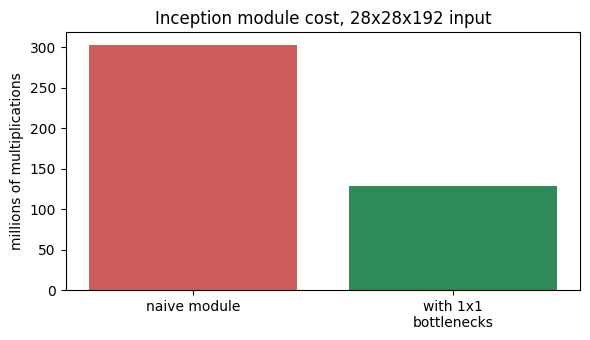

In [11]:
H = W_ = 28
C_IN = 192

# ---- naive module: every branch looks at all 192 input channels
naive = {
    "1x1 (64)":        conv_mults(H, W_, C_IN, 64, 1),
    "3x3 (128)":       conv_mults(H, W_, C_IN, 128, 3),
    "5x5 (32)":        conv_mults(H, W_, C_IN, 32, 5),
}
# (the naive pooling branch would keep all 192 channels; it has no multiplications)

# ---- with 1x1 bottlenecks
bottle = {
    "1x1 (64)":              conv_mults(H, W_, C_IN, 64, 1),
    "3x3 reduce 1x1 (96)":   conv_mults(H, W_, C_IN, 96, 1),
    "3x3 (128)":             conv_mults(H, W_, 96, 128, 3),
    "5x5 reduce 1x1 (16)":   conv_mults(H, W_, C_IN, 16, 1),
    "5x5 (32)":              conv_mults(H, W_, 16, 32, 5),
    "pool proj 1x1 (32)":    conv_mults(H, W_, C_IN, 32, 1),
}

print("Naive Inception module (28x28x192 in):")
for k, v in naive.items():
    print(f"  {k:<22} {v:>13,}")
naive_total = sum(naive.values())
print(f"  {'TOTAL':<22} {naive_total:>13,}\n")

print("With 1x1 bottlenecks:")
for k, v in bottle.items():
    print(f"  {k:<22} {v:>13,}")
bottle_total = sum(bottle.values())
print(f"  {'TOTAL':<22} {bottle_total:>13,}\n")
print(f"Savings: {naive_total / bottle_total:.1f}x fewer multiplications "
      f"({naive_total/1e6:.0f}M -> {bottle_total/1e6:.0f}M)")
print("(The naive pooling branch would also keep all 192 channels, so the naive output would be "
      f"{64 + 128 + 32 + 192} channels wide instead of {64 + 128 + 32 + 32}.)")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(["naive module", "with 1x1\nbottlenecks"], [naive_total / 1e6, bottle_total / 1e6],
       color=["indianred", "seagreen"])
ax.set_ylabel("millions of multiplications")
ax.set_title("Inception module cost, 28x28x192 input")
plt.tight_layout()
plt.show()

## 7. Inception Network

An **Inception module** is the four-branch block from Section 6:

```
                      +--> 1x1 conv (64) -------------------------------------+
                      |                                                       |
input 28x28x192 ------+--> 1x1 conv (96) -> 3x3 conv (128) -------------------+--> concat --> 28x28x256
                      |                                                       |
                      +--> 1x1 conv (16) -> 5x5 conv (32) --------------------+
                      |                                                       |
                      +--> 3x3 max pool (s=1, same) -> 1x1 conv (32) ---------+
```

The **Inception network** (GoogLeNet) is simply many of these modules stacked, with an occasional max pool in between to shrink height and width. It also has **side branches**: a few layers that branch off from a hidden layer and make their own softmax prediction. They act as a regularizer and push useful gradient into the middle of the network. The name comes from the "we need to go deeper" meme in the movie *Inception*.

Below is the module's forward pass in NumPy, using the vectorized `conv_forward` from Section 3.

In [12]:
def max_pool_same(A, f=3):
    """Max pool with stride 1 and 'same' padding, so height and width are unchanged."""
    m, H, Wd, C = A.shape
    p = f // 2
    Ap = np.pad(A, ((0, 0), (p, p), (p, p), (0, 0)), constant_values=-np.inf)
    out = np.full_like(A, -np.inf)
    for di in range(f):
        for dj in range(f):
            out = np.maximum(out, Ap[:, di:di + H, dj:dj + Wd, :])
    return out

def init_inception(c_in, c1, c3_red, c3, c5_red, c5, c_pool, seed=0):
    """He-initialized weights for one Inception module."""
    rng = np.random.RandomState(seed)
    def w(f, ci, co):
        return rng.randn(f, f, ci, co) * np.sqrt(2.0 / (f * f * ci)), np.zeros(co)
    return {
        "b1":      w(1, c_in, c1),
        "b2_red":  w(1, c_in, c3_red), "b2": w(3, c3_red, c3),
        "b3_red":  w(1, c_in, c5_red), "b3": w(5, c5_red, c5),
        "b4_proj": w(1, c_in, c_pool),
    }

def inception_forward(A, P):
    """Four parallel branches, concatenated along the channel axis."""
    branch1 = relu(conv_forward(A, *P["b1"], pad=0)[0])
    branch2 = relu(conv_forward(relu(conv_forward(A, *P["b2_red"], pad=0)[0]), *P["b2"], pad=1)[0])
    branch3 = relu(conv_forward(relu(conv_forward(A, *P["b3_red"], pad=0)[0]), *P["b3"], pad=2)[0])
    branch4 = relu(conv_forward(max_pool_same(A, 3), *P["b4_proj"], pad=0)[0])
    out = np.concatenate([branch1, branch2, branch3, branch4], axis=3)
    return out, [branch1, branch2, branch3, branch4]

P = init_inception(c_in=192, c1=64, c3_red=96, c3=128, c5_red=16, c5=32, c_pool=32)
A = np.random.RandomState(1).randn(1, 28, 28, 192)

t0 = time.time()
out, branches = inception_forward(A, P)
print(f"forward pass took {time.time() - t0:.2f}s\n")

print(f"{'branch':<30} | {'output shape':>14}")
print("-" * 48)
for name, br in zip(["1x1", "1x1 reduce -> 3x3", "1x1 reduce -> 5x5", "3x3 pool -> 1x1 proj"], branches):
    print(f"{name:<30} | {str(br.shape[1:]):>14}")
print("-" * 48)
print(f"{'concatenated output':<30} | {str(out.shape[1:]):>14}   (64 + 128 + 32 + 32 = {64 + 128 + 32 + 32} channels)")

n_params = sum(w.size + b.size for w, b in P.values())
print(f"\nparameters in this module: {n_params:,}")
print(f"for comparison, one plain 5x5 conv 192 -> 256 would have {conv_params(5, 192, 256):,}")
print(f"and a 3x3 conv 192 -> 256 would have {conv_params(3, 192, 256):,}")

forward pass took 0.03s

branch                         |   output shape
------------------------------------------------
1x1                            |   (28, 28, 64)
1x1 reduce -> 3x3              |  (28, 28, 128)
1x1 reduce -> 5x5              |   (28, 28, 32)
3x3 pool -> 1x1 proj           |   (28, 28, 32)
------------------------------------------------
concatenated output            |  (28, 28, 256)   (64 + 128 + 32 + 32 = 256 channels)

parameters in this module: 163,696
for comparison, one plain 5x5 conv 192 -> 256 would have 1,229,056
and a 3x3 conv 192 -> 256 would have 442,624


In [13]:
# Stack two modules with a max pool in between: the "Inception network" skeleton.
def max_pool2(A):
    m, H, Wd, C = A.shape
    return A[:, :H // 2 * 2, :Wd // 2 * 2, :].reshape(m, H // 2, 2, Wd // 2, 2, C).max(axis=(2, 4))

P1 = init_inception(192, 64, 96, 128, 16, 32, 32, seed=1)      # out: 256 channels
P2 = init_inception(256, 128, 128, 192, 32, 96, 64, seed=2)    # out: 128 + 192 + 96 + 64 = 480 channels

x = np.random.RandomState(5).randn(1, 28, 28, 192)
h1, _ = inception_forward(x, P1)
pooled = max_pool2(h1)
h2, _ = inception_forward(pooled, P2)
print("input                      :", x.shape[1:])
print("inception module 1         :", h1.shape[1:])
print("max pool 2x2               :", pooled.shape[1:], "  <- height/width shrink between modules")
print("inception module 2         :", h2.shape[1:])
print("\nThe shape pattern is the same as in LeNet and VGG (height and width down, channels up),")
print("but each stage now chooses its own mix of 1x1 / 3x3 / 5x5 / pooling features.")

input                      : (28, 28, 192)
inception module 1         : (28, 28, 256)
max pool 2x2               : (14, 14, 256)   <- height/width shrink between modules
inception module 2         : (14, 14, 480)

The shape pattern is the same as in LeNet and VGG (height and width down, channels up),
but each stage now chooses its own mix of 1x1 / 3x3 / 5x5 / pooling features.


## 8. Using Open Source Implementations

Nobody trains ResNet-152 from scratch on a laptop. In practice the workflow is:

1. **Find the paper's open-source implementation** on GitHub (or a model zoo: torchvision, Keras Applications, timm, Hugging Face). Neural network details are fiddly (initialization, learning rate schedules, data preprocessing, tiny details the paper doesn't mention); someone else has already spent weeks getting them right.
2. **Download pretrained weights** (usually trained on ImageNet, 1000 classes, 1.2 million images). Training from scratch can take days on multiple GPUs; downloading takes seconds.
3. **Use them as the starting point** for your problem (Section 9).

What does "downloading pretrained weights" actually mean? Just a file full of arrays: for each layer, a weight array and a bias array, stored under a name. Loading means putting those arrays into a network *with the same architecture*. In real libraries it looks like this (not run here, no internet needed for this notebook):

```python
import torchvision
model = torchvision.models.resnet50(weights="IMAGENET1K_V2")    # architecture + pretrained weights, one line
```

Things worth checking before using someone's code: the **license**, the **input preprocessing** it expects (image size, mean/std normalization, channel order), and the **class list** it was trained on.

To make this concrete without any download, this section does the whole cycle in miniature: builds a small CNN, trains it on a **source task** (circles vs squares), **saves** the weights to a file as "the released model", then **loads** them into a fresh network. Section 9 reuses that file for a different task.

First the small CNN engine used for both sections: conv -> ReLU -> max pool, twice, then a dense output layer. It uses the vectorized `conv_forward` / `conv_backward` from Section 3. The dense layer's gradient and Adam are the same ones from the earlier notebooks, and the loss is a mean over the batch, so the $1/m$ lives in `dout` (the gradient with respect to the network output).

In [14]:
def maxpool2_forward(A):
    """2x2 max pool, stride 2 (needs even height and width)."""
    m, H, Wd, C = A.shape
    R = A.reshape(m, H // 2, 2, Wd // 2, 2, C)
    out = R.max(axis=(2, 4))
    return out, (R, out)

def maxpool2_backward(dout, cache):
    """Route the gradient only to the position that held the max."""
    R, out = cache
    mask = (R == out[:, :, None, :, None, :])
    dR = mask * dout[:, :, None, :, None, :]
    m, h2, _, w2, _, C = R.shape
    return dR.reshape(m, h2 * 2, w2 * 2, C)

def init_net(img_size, c_in, n_out, f1=4, f2=8, pad=1, seed=1):
    """conv3x3(f1) -> relu -> pool -> conv3x3(f2) -> relu -> pool -> flatten -> dense(n_out)"""
    rng = np.random.RandomState(seed)
    s1 = img_size + 2 * pad - 2
    s2 = s1 // 2 + 2 * pad - 2
    flat = (s2 // 2) ** 2 * f2
    return {
        "W1": rng.randn(3, 3, c_in, f1) * np.sqrt(2.0 / (9 * c_in)), "b1": np.zeros(f1),
        "W2": rng.randn(3, 3, f1, f2) * np.sqrt(2.0 / (9 * f1)),     "b2": np.zeros(f2),
        "O_W": rng.randn(n_out, flat) * np.sqrt(1.0 / flat),         "O_b": np.zeros((n_out, 1)),
    }

def net_forward(X, P, pad=1):
    Z1, c1 = conv_forward(X, P["W1"], P["b1"], pad)
    A1 = relu(Z1)
    P1, pc1 = maxpool2_forward(A1)
    Z2, c2 = conv_forward(P1, P["W2"], P["b2"], pad)
    A2 = relu(Z2)
    P2, pc2 = maxpool2_forward(A2)
    flat = P2.reshape(X.shape[0], -1).T                        # (flat, m)
    out = P["O_W"] @ flat + P["O_b"]                           # (n_out, m)
    cache = dict(c1=c1, Z1=Z1, pc1=pc1, c2=c2, Z2=Z2, pc2=pc2, P2_shape=P2.shape, flat=flat)
    return out, cache

def net_backward(dout, cache, P):
    G = {}
    G["O_W"] = dout @ cache["flat"].T
    G["O_b"] = dout.sum(axis=1, keepdims=True)
    dP2 = (P["O_W"].T @ dout).T.reshape(cache["P2_shape"])
    dZ2 = maxpool2_backward(dP2, cache["pc2"]) * (cache["Z2"] > 0)
    dP1, G["W2"], G["b2"] = conv_backward(dZ2, cache["c2"])
    dZ1 = maxpool2_backward(dP1, cache["pc1"]) * (cache["Z1"] > 0)
    _, G["W1"], G["b1"] = conv_backward(dZ1, cache["c1"])
    return G

def bce_loss(out, Y):
    """Binary cross-entropy on logits. Returns (loss, dLoss/dout)."""
    m = Y.shape[1]
    A = sigmoid(out)
    Ac = np.clip(A, 1e-8, 1 - 1e-8)
    loss = -np.sum(Y * np.log(Ac) + (1 - Y) * np.log(1 - Ac)) / m
    return loss, (A - Y) / m

def adam_init(P):
    return {"t": 0, "m": {k: np.zeros_like(v) for k, v in P.items()},
            "v": {k: np.zeros_like(v) for k, v in P.items()}}

def adam_step(P, G, state, alpha=0.01, b1=0.9, b2=0.999, eps=1e-8, frozen=()):
    state["t"] += 1
    t = state["t"]
    for k in P:
        if k in frozen:
            continue                                           # frozen layers are simply not updated
        state["m"][k] = b1 * state["m"][k] + (1 - b1) * G[k]
        state["v"][k] = b2 * state["v"][k] + (1 - b2) * G[k] ** 2
        m_hat = state["m"][k] / (1 - b1 ** t)
        v_hat = state["v"][k] / (1 - b2 ** t)
        P[k] -= alpha * m_hat / (np.sqrt(v_hat) + eps)

def train_net(X, Y, P, iters=200, alpha=0.01, pad=1, frozen=()):
    state = adam_init(P)
    costs = []
    for _ in range(iters):
        out, cache = net_forward(X, P, pad)
        loss, dout = bce_loss(out, Y)
        G = net_backward(dout, cache, P)
        adam_step(P, G, state, alpha, frozen=frozen)
        costs.append(loss)
    return P, costs

def accuracy(X, Y, P, pad=1):
    out, _ = net_forward(X, P, pad)
    return float(np.mean((sigmoid(out) > 0.5) == (Y > 0.5)))

def copy_params(P):
    return {k: v.copy() for k, v in P.items()}

# ---- gradient checking, as in the previous notebook, before trusting any training run
def grad_check(X, Y, P, pad=1, n_checks=4, eps=1e-5, seed=0):
    out, cache = net_forward(X, P, pad)
    _, dout = bce_loss(out, Y)
    G = net_backward(dout, cache, P)
    rng = np.random.RandomState(seed)
    print(f"{'param':>5} | {'analytic':>12} | {'numeric':>12} | {'rel. diff':>10}")
    worst = 0
    for name in P:
        for _ in range(n_checks):
            idx = tuple(rng.randint(0, s) for s in P[name].shape)
            old = P[name][idx]
            P[name][idx] = old + eps; lp = bce_loss(net_forward(X, P, pad)[0], Y)[0]
            P[name][idx] = old - eps; lm = bce_loss(net_forward(X, P, pad)[0], Y)[0]
            P[name][idx] = old
            num, ana = (lp - lm) / (2 * eps), G[name][idx]
            rel = abs(num - ana) / max(1e-8, abs(num) + abs(ana))
            worst = max(worst, rel)
            print(f"{name:>5} | {ana:>12.6f} | {num:>12.6f} | {rel:>10.2e}")
    print(f"\nworst relative difference: {worst:.2e}  ->  {'OK' if worst < 1e-4 else 'CHECK THE BACKPROP'}")

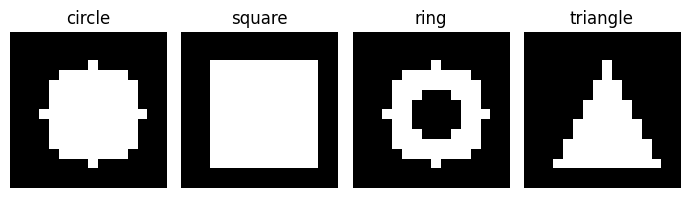

param |     analytic |      numeric |  rel. diff
   W1 |     0.057569 |     0.057569 |   6.77e-11
   W1 |     0.032570 |     0.032570 |   1.31e-10
   W1 |     0.072281 |     0.072281 |   1.25e-11
   W1 |     0.024105 |     0.024105 |   3.68e-11
   b1 |     0.031336 |     0.031336 |   1.23e-10
   b1 |    -0.019576 |    -0.019576 |   7.02e-11
   b1 |    -0.019576 |    -0.019576 |   7.02e-11
   b1 |    -0.038562 |    -0.038562 |   8.21e-11
   W2 |     0.008624 |     0.008624 |   7.94e-10
   W2 |    -0.000557 |    -0.000557 |   7.21e-09
   W2 |    -0.006744 |    -0.006744 |   9.87e-11
   W2 |     0.027696 |     0.027696 |   1.05e-11
   b2 |     0.038766 |     0.038766 |   2.82e-11
   b2 |     0.055052 |     0.055052 |   8.53e-11
   b2 |     0.038766 |     0.038766 |   2.82e-11
   b2 |     0.038766 |     0.038766 |   2.82e-11
  O_W |    -0.008485 |    -0.008485 |   2.20e-10
  O_W |    -0.035462 |    -0.035462 |   2.09e-11
  O_W |    -0.007696 |    -0.007696 |   3.12e-10
  O_W |     0.002337

In [15]:
# ---- synthetic shape images (16x16, one channel): circle, square, ring, triangle
def draw_shape(size, shape, cx, cy, r):
    yy, xx = np.mgrid[0:size, 0:size]
    d2 = (xx - cx) ** 2 + (yy - cy) ** 2
    if shape == "circle":
        return d2 <= r * r
    if shape == "ring":
        return (d2 <= r * r) & (d2 >= (0.55 * r) ** 2)
    if shape == "square":
        return (np.abs(xx - cx) <= r) & (np.abs(yy - cy) <= r)
    if shape == "triangle":                                    # apex up, base down
        t = (yy - (cy - r)) / (2.0 * r)                        # 0 at the apex, 1 at the base
        return (t >= 0) & (t <= 1) & (np.abs(xx - cx) <= t * r)
    raise ValueError(shape)

def make_dataset(pos, neg, n_per_class, size=16, seed=0):
    """Label 1 = `pos` shape, label 0 = `neg` shape. X: (m, size, size, 1), Y: (1, m)."""
    rng = np.random.RandomState(seed)
    X, Y = [], []
    for label, shape in ((1, pos), (0, neg)):
        for _ in range(n_per_class):
            cx, cy = rng.randint(size // 3, 2 * size // 3 + 1, size=2)
            r = rng.randint(size // 5, size // 3 + 1)
            img = draw_shape(size, shape, cx, cy, r).astype(float) + 0.05 * rng.randn(size, size)
            X.append(img[:, :, None]); Y.append(label)
    X, Y = np.array(X), np.array(Y)[None, :]
    order = rng.permutation(len(Y[0]))
    return X[order], Y[:, order]

fig, axes = plt.subplots(1, 4, figsize=(7, 2))
for ax, shape in zip(axes, ["circle", "square", "ring", "triangle"]):
    ax.imshow(draw_shape(16, shape, 8, 8, 5), cmap="gray"); ax.set_title(shape); ax.axis("off")
plt.tight_layout()
plt.show()

# ---- gradient check on a tiny batch
# Use small NON-ZERO biases here. With b = 0, dead regions have Z exactly 0, which sits right on the ReLU
# kink: nudging b by +eps or -eps lands on different sides of it and the finite difference is meaningless
# (the backprop is fine, the *numerical* estimate is not).
X_chk, Y_chk = make_dataset("circle", "square", 3, seed=11)
P_chk = init_net(16, 1, 1, f1=3, f2=4, seed=2)
rng_chk = np.random.RandomState(4)
P_chk["b1"] = 0.1 * rng_chk.randn(3)
P_chk["b2"] = 0.1 * rng_chk.randn(4)
grad_check(X_chk, Y_chk, P_chk)

trained on 600 images in 26.0s
source task  train accuracy: 1.000   dev accuracy: 1.000
saved: ['O_W', 'O_b', 'W1', 'W2', 'b1', 'b2']

before loading, fresh network dev accuracy: 0.500 (random weights)
after loading,  fresh network dev accuracy: 1.000
predictions identical to the original model: True


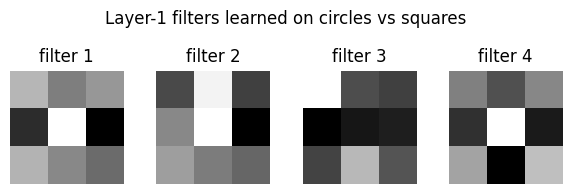

In [16]:
# ---- SOURCE TASK: circles (1) vs squares (0), plenty of data. This plays the role of "ImageNet".
X_src, Y_src = make_dataset("circle", "square", 300, seed=100)
X_src_dev, Y_src_dev = make_dataset("circle", "square", 100, seed=101)

source = init_net(16, 1, 1, f1=4, f2=8, seed=5)
t0 = time.time()
source, costs = train_net(X_src, Y_src, source, iters=150, alpha=0.01)
print(f"trained on {X_src.shape[0]} images in {time.time() - t0:.1f}s")
print(f"source task  train accuracy: {accuracy(X_src, Y_src, source):.3f}   dev accuracy: {accuracy(X_src_dev, Y_src_dev, source):.3f}")

# ---- "release" the weights: an .npz file is just named arrays
np.savez("source_cnn_weights.npz", **source)
print("saved:", sorted(np.load("source_cnn_weights.npz").files))

# ---- someone else downloads the file and loads it into a fresh network with the SAME architecture
downloaded = dict(np.load("source_cnn_weights.npz"))
fresh = init_net(16, 1, 1, f1=4, f2=8, seed=999)              # different random init
print("\nbefore loading, fresh network dev accuracy:", f"{accuracy(X_src_dev, Y_src_dev, fresh):.3f}", "(random weights)")
fresh.update(downloaded)                                      # load pretrained weights
print("after loading,  fresh network dev accuracy:", f"{accuracy(X_src_dev, Y_src_dev, fresh):.3f}")

same = np.allclose(net_forward(X_src_dev, fresh)[0], net_forward(X_src_dev, source)[0])
print("predictions identical to the original model:", same)

# ---- what did the first layer learn? (4 filters of size 3x3)
fig, axes = plt.subplots(1, 4, figsize=(6, 1.8))
for k, ax in enumerate(axes):
    ax.imshow(downloaded["W1"][:, :, 0, k], cmap="gray"); ax.set_title(f"filter {k + 1}"); ax.axis("off")
plt.suptitle("Layer-1 filters learned on circles vs squares", y=1.05)
plt.tight_layout()
plt.show()

## 9. Transfer Learning

You have a new task with **very little data**. Training a CNN from scratch on a handful of images will overfit. Instead, reuse a network trained on a big dataset. The early layers of a CNN learn general-purpose features (edges, corners, curves, textures) that are useful for many tasks; only the final layers are specific to the original labels.

How much you reuse depends on how much data you have:

| Your data | Recipe |
|---|---|
| **Very little** | Freeze all pretrained layers, replace the output layer, **train only the new layer** (treat the frozen network as a fixed feature extractor) |
| **A moderate amount** | Freeze the early layers, train the later ones plus the new output layer |
| **A lot** | Use the pretrained weights only as the **initialization** and fine-tune everything (with a smaller learning rate) |

A practical trick for the frozen part: since frozen layers never change, you can compute their output for every training image **once**, save it, and train only the small head on those saved features. (The code below just skips updating frozen layers, which is simpler.)

The experiment: the pretrained model from Section 8 knows circles vs squares. The new task is **ring vs triangle**, with only 5 training images per class. We compare three strategies on the same data, repeated over several random training sets because with so few images any single run is noisy.

8 trials x 3 strategies in 12s

New task: ring vs triangle, 10 training images, 200 dev images
strategy                     | mean dev acc |    std |    min |    max
----------------------------------------------------------------------
scratch                      |        0.801 |  0.061 |  0.705 |  0.865
frozen (train head only)     |        0.863 |  0.067 |  0.745 |  0.950
fine-tune everything         |        0.843 |  0.088 |  0.665 |  0.935

frozen (train head only) vs scratch, same training sets: better in 7/8 trials, mean difference +0.063 (std of difference 0.035)

fine-tune everything vs scratch, same training sets: better in 7/8 trials, mean difference +0.043 (std of difference 0.052)

How to read this: the pretrained features are a head start on tiny data, but the effect here is modest
and noisy (8 trials, a toy source task). The point is the mechanism and the recipe, not the exact numbers.
The more similar the source and target tasks, and the less target data you have, the 

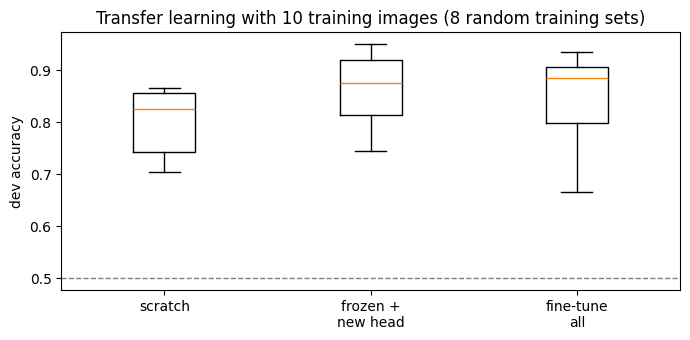

In [17]:
def new_head(P, seed):
    """Copy the pretrained network and replace its output layer with a fresh random one."""
    Q = copy_params(P)
    flat = Q["O_W"].shape[1]
    rng = np.random.RandomState(seed)
    Q["O_W"] = rng.randn(1, flat) * np.sqrt(1.0 / flat)
    Q["O_b"] = np.zeros((1, 1))
    return Q

X_dev, Y_dev = make_dataset("ring", "triangle", 100, seed=500)      # 200 dev images, never used for training
n_per_class, n_trials, iters = 5, 8, 150
conv_layers = ("W1", "b1", "W2", "b2")

results = {"scratch": [], "frozen (train head only)": [], "fine-tune everything": []}
t0 = time.time()
for trial in range(n_trials):
    X_tr, Y_tr = make_dataset("ring", "triangle", n_per_class, seed=1000 + trial)

    # (a) from scratch: random init, train every layer
    P_a = init_net(16, 1, 1, f1=4, f2=8, seed=trial)
    P_a, _ = train_net(X_tr, Y_tr, P_a, iters=iters, alpha=0.01)
    results["scratch"].append(accuracy(X_dev, Y_dev, P_a))

    # (b) pretrained conv layers frozen, only the new output layer is trained
    P_b = new_head(source, seed=trial)
    P_b, _ = train_net(X_tr, Y_tr, P_b, iters=iters, alpha=0.01, frozen=conv_layers)
    results["frozen (train head only)"].append(accuracy(X_dev, Y_dev, P_b))

    # (c) pretrained weights as initialization, fine-tune everything with a smaller learning rate
    P_c = new_head(source, seed=trial)
    P_c, _ = train_net(X_tr, Y_tr, P_c, iters=iters, alpha=0.003)
    results["fine-tune everything"].append(accuracy(X_dev, Y_dev, P_c))
print(f"{n_trials} trials x 3 strategies in {time.time() - t0:.0f}s\n")

print(f"New task: ring vs triangle, {2 * n_per_class} training images, 200 dev images")
print(f"{'strategy':<28} | {'mean dev acc':>12} | {'std':>6} | {'min':>6} | {'max':>6}")
print("-" * 70)
for name, accs in results.items():
    accs = np.array(accs)
    print(f"{name:<28} | {accs.mean():>12.3f} | {accs.std():>6.3f} | {accs.min():>6.3f} | {accs.max():>6.3f}")

scratch_acc = np.array(results["scratch"])
for name in ("frozen (train head only)", "fine-tune everything"):
    diff = np.array(results[name]) - scratch_acc
    wins = int(np.sum(diff > 0))
    print(f"\n{name} vs scratch, same training sets: better in {wins}/{n_trials} trials, "
          f"mean difference {diff.mean():+.3f} (std of difference {diff.std():.3f})")
print("\nHow to read this: the pretrained features are a head start on tiny data, but the effect here is modest")
print("and noisy (8 trials, a toy source task). The point is the mechanism and the recipe, not the exact numbers.")
print("The more similar the source and target tasks, and the less target data you have, the more freezing helps.")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.boxplot(list(results.values()))
ax.set_xticklabels(["scratch", "frozen +\nnew head", "fine-tune\nall"])
ax.axhline(0.5, color="gray", ls="--", lw=1)
ax.set_ylabel("dev accuracy")
ax.set_title(f"Transfer learning with {2 * n_per_class} training images ({n_trials} random training sets)")
plt.tight_layout()
plt.show()